Consider a scenario where we want to predict the price of house given we have the following inputs: <br>
    1. Living Area <br>
    2. # Bedrooms <br>
### Notations:
$x_i$ - Input features where $x_1$ - living area, and $x_2$ - # Bedrooms <br>
$y $ - Target Variable; $ y$ - Price of the house <br>

Our goal is learn a function called hypothesis, that maps our input x to our output y, For Linear Regression, we assume the relationship is a straight line <br>
##### $h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2$

The $\theta$'s are called parameters (also weights). $\theta_0$ is the intercept term, and rest of the parameters determine the slope <br>
We can simply write the above equation as (in vector form)
##### $h_{\theta}(x) = \sum_{i=0}^d \theta_i x_i = \theta^T x$
where $x_0$ = 1 and d is the no of features. <br>
The code for visualizing this is below, but first we will see what's in our data and filter it.

It is advisable to study numpy, matplotlib libraries before using this material but it's fine.

In [2]:
#let's first check what do we have in our california housing data
from sklearn.datasets import fetch_california_housing
#The following lines give us put the data in X_full and target in y_full.
califronia = fetch_california_housing()
X_full = califronia.data
y_full = califronia.target 

print("California Housing Dataset Information")
print(f"Shape: {X_full.shape}") #Returns (number of rows, number of columns)
print(f"Number of Samples: {X_full.shape[0]}") #Printing out the no of rows to see the no of examples
print(f"Number of features: {X_full.shape[1]}") #Printing out the no of columns to see the no of the features
print(f"Feature names:")

for i, name in enumerate(califronia.feature_names):
    print(f"    {i}. {name}")

print(f"Target Variable: {califronia.target_names}")
print(f"Target shape: {y_full.shape}")
print(f"\nData types:")
print(f"  Features (X_full): {X_full.dtype}") #to print out data types
print(f"  Target (y_full): {y_full.dtype}")
print(f"\nTarget value range: [{y_full.min():.3f}, {y_full.max():.3f}]")
print(f"Target description: Median house values in $100,000s")

California Housing Dataset Information
Shape: (20640, 8)
Number of Samples: 20640
Number of features: 8
Feature names:
    0. MedInc
    1. HouseAge
    2. AveRooms
    3. AveBedrms
    4. Population
    5. AveOccup
    6. Latitude
    7. Longitude
Target Variable: ['MedHouseVal']
Target shape: (20640,)

Data types:
  Features (X_full): float64
  Target (y_full): float64

Target value range: [0.150, 5.000]
Target description: Median house values in $100,000s


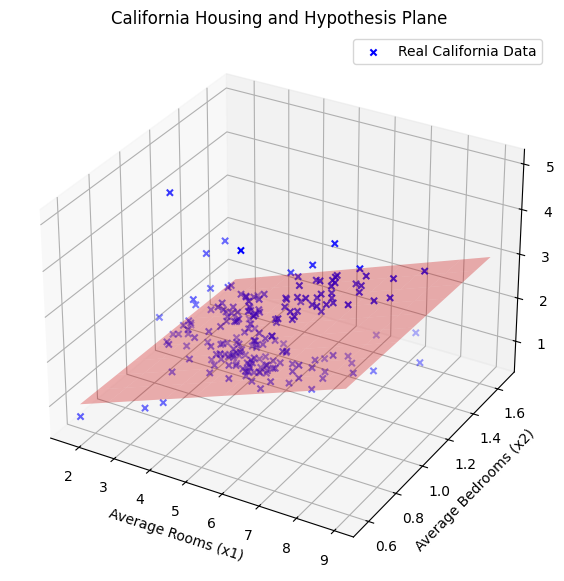

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#Let's just consider two variables for the sake of learning. x1 is average no of rooms and x2 is average no of bedrooms
# Extract AveRooms (index 2) and AveBedrms (index 3)
X1_full = X_full[:, 2]
X2_full = X_full[:, 3]

# 2. Filter out extreme outliers for better vsualization and sample 200 points
mask = (X1_full < 10) & (X2_full < 4) #We are only taking the data where the avg no of rooms are less than 10 and avg no of bed rooms are less than 4
X1 = X1_full[mask][:200]
X2 = X2_full[mask][:200]
y = y_full[mask][:200]

# 3. Pick random parameters for our initial hypothesis plane
theta_0 = 0.5   # Base price in $100k
theta_1 = 0.3   # Price per average room
theta_2 = -0.1  # Price per average bedroom

# 4. Create a meshgrid to plot the hypothesis plane
x1_range = np.linspace(X1.min(), X1.max(), 10)
x2_range = np.linspace(X2.min(), X2.max(), 10)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range) #Creates a 2D grid of all possile combinations of x1_range(), and x2_range()
y_plane = theta_0 + theta_1 * X1_mesh + theta_2 * X2_mesh

# 5. Plot the 3D data and the initial hypothesis plane
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, y, color='blue', marker='x', label='Real California Data')
ax.plot_surface(X1_mesh, X2_mesh, y_plane, color='red', alpha=0.3)

ax.set_xlabel('Average Rooms (x1)')
ax.set_ylabel('Average Bedrooms (x2)')
ax.set_zlabel('Price in $100k (y)')
ax.set_title('California Housing and Hypothesis Plane')
plt.legend()
plt.show()


## The Cost Function

Now that we have our plane, we need a mathematical way to measure how bad our current plane is. <br>
We define a function that measures how close our predictions $h_{\theta}(x^{(i)})$ are to the actual prices $y^{(i)}$. <br>
<br>
We define Cost Function $J(\theta)$ as

##### $ J(\theta) = \frac{1}{2} \sum_{i=1}^n (h_\theta(x^{(i)}) - y^{(i)})^2$

1. The inner error: $h_\theta(x^{(i)}) - y^{(i)}$ calculates the vertical distance between our plane's prediction point and actual data point for a single house. <br>
2. The Summation: $\sum_{i = 1}^n$ iterates through all of our n examples in the training set and adds their errors together. <br>
3. We square the inner error to remove the negative values and also because it punishes large errors a lot <br>
4. The fraction 1/2 will make the calculation easier in the next step. <br>
This specific formulation is called the least square cost function. <br>

## Gradient Descent (The LMS Algorithm)
We need to make a search algorithm that starts with our initial guess for $\theta$ and repeatedly change to make $J(\theta)$ smaller, hopefully converging it to the minimum. <br>

To do this, we will use the Gradient Descent Algorithm. The idea is to calculate the slope (the gradeint) of our cost function at our current position and take a step down.<br>
We will look at one single training example to keep it clean. We need to find the partial derivative of J($\theta$) with respect to specific parameter $\theta_j$ <br>
##### $\frac{\partial}{\partial \theta_j} J(\theta) = \frac{\partial}{\partial \theta_j} \frac{1}{2} (h_{\theta}(x) - y)^2$ 
##### $2.\frac{1}{2}(h_{\theta}(x) - y) \frac{\partial}{\partial \theta_j} \frac{1}{2} (h_{\theta}(x) - y) $
Substitute $h_{\theta}(x) = \sum_{i = 0}^n\theta_i x_i$
then you would get <br>
##### $(h_\theta(x) - y) \cdot \frac{\partial}{\partial \theta_j} \left( \sum_{i=0}^d \theta_i x_i - y \right)$
##### $ (h_\theta(x) - y) x_j$

To get a step down from the slope, we subtract this gradient from our current parameter. Here $\alpha$ is the learning rate, which controls our how big our step is gonna be
##### $\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} $
Plug in our derivate and you get
##### $\theta_j := \theta_j + \alpha (y - h_{\theta}(x))x_j$

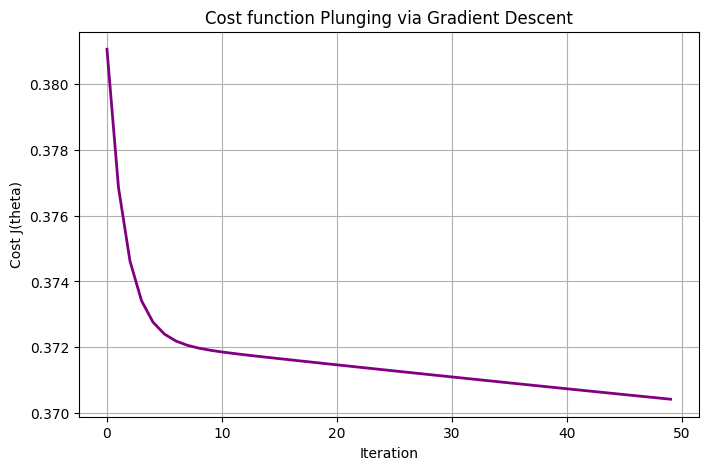

Optimized parameters: theta_0=0.499, theta_1=0.332, theta_2=-0.124
Initial cost: 0.3810
Final cost: 0.3704


In [6]:
#Applying this to our database of n houses, we just sum up the gradients for all the examples before taking a step. This is called Batch Gradient Descent.
california = fetch_california_housing()
X_full = california.data
y_full = california.target

mask = (X_full[:, 2] < 10) & (X_full[:,3] < 3) #making X store 2nd and 3rd columns of the data only if the 2nd column has a number less than 10 and if the the 3rd has a number less than 3
X1 = X_full[mask, 2][:200] 
X2 = X_full[mask, 3][:200]
y = y_full[mask][:200]

n = len(y) #no of examples to train

#Adding x_0 = 1 to our feature matrix so we can use vector dot products
X0 = np.ones(n)
X_matrix = np.column_stack((X0, X1, X2))

# 3. Initialize parameters and hyperparameters
theta = np.array([0.5, 0.3, -0.1])
alpha = 0.01 #Learning rate
iterations = 50

cost_history = []

for i in range(iterations):
    predictions = X_matrix.dot(theta)
    cost_function = np.sum((predictions - y)** 2) / (2 * n)
    cost_history.append(cost_function)
    gradient = (X_matrix.T.dot(predictions - y)) / n
    theta = theta - alpha * gradient

#Plotting the cost dropping over time
plt.figure(figsize=(8,5))
plt.plot(range(iterations), cost_history, color = 'purple', linewidth = 2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title("Cost function Plunging via Gradient Descent")
plt.grid(True)
plt.show()

print(f"Optimized parameters: theta_0={theta[0]:.3f}, theta_1={theta[1]:.3f}, theta_2={theta[2]:.3f}")
print(f"Initial cost: {cost_history[0]:.4f}")
print(f"Final cost: {cost_history[-1]:.4f}")


### The Normal Equations (The Closed - Form Solution)

Gradient Descent is fantastic, but iterating through loops takes time. Since our cost function is a perfect convex bowl, we can actually use calculus and linear algebra to jump straight to the exact bottom of the bowl in a single step, without resorting to an iterative algorithm.

In order to do this efficiently, we write our entire dataset and cost function using matrices and vectors.

Let X be our design matrix. It is an n-by-(d + 1) matrix containing all our training example, where each row is a house

##### $X = \begin{bmatrix} -(x^{(1)})^T- \\ -(x^{(2)})^T- \\ \vdots \\ -(x^{(n)})^T- \end{bmatrix}$

Let y be the n-dimensional vector containing all the target prices
##### $ y = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)}\end{bmatrix} $
We can calculate the predictions for every single house at once by multiplying X $\theta$ <br>
Now our least-squares cost function J($\theta$) can be written in vector form as
##### $J(\theta) = \frac{1}{2}(X\theta - y)^T(X\theta - y)$